[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/viscoelastic-startup/blob/main/notebooks/jordan_2005_second_grade_couette.ipynb)

# LEARNING OBJECTIVE

After exploring this notebook, you will be able to regenerate, from scratch, the correct series solution for the start-up of plane Couette flow of a second-grade fluid and the erroneous series it corrects, as discussed by [Jordan (2005)](https://doi.org/10.1155/MPE.2005.539), verify the correct one against a numerical inversion of the Laplace transform and a finite-difference scheme, show that the erroneous one misses the start-up jump, reproduce Figs. 5.1&ndash;5.4 of that paper, and identify the problem the erroneous series actually solves.

The start-up jump is not a peculiarity of the half-space: in a channel it is a layer of thickness $l = \sqrt{\alpha}/h$ at the moving plate, and a series that starts the fluid from rest cannot have it.

# PRELIMINARIES

This notebook uses [NumPy](https://numpy.org) ([Harris _et al._, 2020](https://doi.org/10.1038/s41586-020-2649-2)), [SciPy](https://scipy.org) ([Virtanen _et al._, 2020](https://doi.org/10.1038/s41592-019-0686-2)), [SymPy](https://www.sympy.org) ([Meurer _et al._, 2017](https://doi.org/10.7717/peerj-cs.103)), [Matplotlib](https://matplotlib.org) ([Hunter, 2007](https://doi.org/10.1109/MCSE.2007.55)) and [mpmath](https://mpmath.org) ([mpmath development team, 2023](https://mpmath.org/)).

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# plotting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# for animations
from IPython.display import HTML

# numerics
import numpy as np
from scipy.linalg import solve_banded
import mpmath as mp
import os

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version of this notebook written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

Reproducing results of P. M. Jordan.

# THE PROBLEM

The initial-boundary-value problem (IBVP), Eqs. (2.1)&ndash;(2.2) of Jordan (2005), for the velocity $u(y,t)$ of a second-grade fluid between a fixed plate at $y = 0$ and a plate at $y = h$ suddenly moved with velocity $U$:
\begin{align*}
    \frac{\partial u}{\partial t} &= \nu \frac{\partial^2 u}{\partial y^2} + \alpha \frac{\partial^3 u}{\partial t\partial y^2}, \qquad (y,t) \in (0,h) \times (0, \infty),\\
    u(0,t) &= 0,\qquad u(h,t) = UH(t),\qquad t > 0;\qquad u(y,0) = 0,\qquad y \in (0,h),
\end{align*}
(correcting the misprint in the published Eq. (2.1), whose last derivative reads $\partial^3 u/\partial t\partial x^2$), where $H(t)$ is the [Heaviside step function](https://en.wikipedia.org/wiki/Heaviside_step_function), $\nu$ the kinematic viscosity and $\alpha = \alpha_1/\rho$. The dimensionless variables are
$$
    \eta = \frac{y}{h},\qquad \tau = \frac{\nu t}{h^2},\qquad l = \frac{\sqrt{\alpha}}{h},
$$
and the velocity is $U^{-1}u$. The figures of the paper use $l = \sqrt{0.01}$ and $\tau = 0.01$, $0.1$, $0.5$, $1$.

# THE ERRONEOUS SOLUTION

> &#x26A0;&#xFE0F; **ERRONEOUS SOLUTION, reproduced as printed** in Eq. (16) of Hayat, Khan, Siddiqui & Asghar (2004) ([doi:10.1016/j.ijnonlinmec.2002.12.001](https://doi.org/10.1016/j.ijnonlinmec.2002.12.001)), p. 1623. Jordan (2005) points out that its denominators contain only $n$ instead of $n(1+l^2n^2\pi^2)$. It is shown below to be wrong.

$$
    \frac{u}{U} = \frac{y}{h} + \frac{2}{\pi}\sum_{n=1}^\infty \frac{(-1)^n}{n}\exp\left(\frac{-n^2\pi^2\beta_1 t}{h^2}\right)\sin\frac{n\pi}{h}y,\qquad
    \beta_1 = \mu\left[\rho + \alpha_1\left(\frac{n\pi}{h}\right)^2\right]^{-1}.
$$

In [2]:
# WRONG, as printed: Eq. (16) of Hayat, Khan, Siddiqui & Asghar (2004)
def wrong_hayat_16(y, t, h=1.0, rho=1.0, mu=1.0, alpha1=0.01, nterms=100):
    """Erroneous solution, as printed: Eq. (16) of Hayat et al. (2004), u/U."""
    u = y/h
    for n in range(1, nterms + 1):
        beta1 = mu/(rho + alpha1*(n*np.pi/h)**2)
        u = u + 2/np.pi*(-1)**n/n*np.exp(-n**2*np.pi**2*beta1*t/h**2)*np.sin(n*np.pi*y/h)
    return u

With $h = \rho = \mu = 1$ (so that $y = \eta$, $t = \tau$) and $\alpha_1 = l^2$, this is a function of $\eta$, $\tau$ and $l$.

> &#x26A0;&#xFE0F; **END OF THE ERRONEOUS SOLUTION.** The cells below are correct.

# THE CORRECT SOLUTION

The [Laplace transform](https://en.wikipedia.org/wiki/Laplace_transform) of the IBVP gives the transform-domain solution, Eq. (3.1) of Jordan (2005),
$$
    U^{-1}\bar{u}(\eta,s) = \frac{1}{s}\,\frac{\sinh\left[\eta\sqrt{s/(1+sl^2)}\right]}{\sinh\left[\sqrt{s/(1+sl^2)}\right]},
$$
with simple poles at, Eq. (3.2), $s_n = -n^2\pi^2/(1+l^2n^2\pi^2)$, $n = 0, 1, 2, \dots$ The next cell checks with SymPy that Eq. (3.1) solves the transformed IBVP, $s\bar{u} = (1+l^2s)\frac{\partial^2\bar{u}}{\partial\eta^2}$ with $\bar{u}(0,s) = 0$ and $\bar{u}(1,s) = 1/s$; it should print three zeros.

In [3]:
# Eq. (3.1) of Jordan (2005) solves the Laplace transform of the IBVP (2.1)-(2.2)
s, l, eta, tau = sp.symbols('s l eta tau', positive=True)
n = sp.Symbol('n', integer=True, positive=True)
z = sp.sqrt(s/(1 + s*l**2))
ubar_sym = sp.sinh(eta*z)/(s*sp.sinh(z))
(sp.simplify(s*ubar_sym - (1 + l**2*s)*ubar_sym.diff(eta, 2)), ubar_sym.subs(eta, 0), sp.simplify(ubar_sym.subs(eta, 1) - 1/s))

Evaluating the residues gives the correct solution, Eq. (3.3) of Jordan (2005) (from [Jordan & Puri (2002)](https://doi.org/10.1098/rspa.2001.0917)),
$$
    U^{-1}u(\eta,\tau) = H(\tau)\left\{\eta + \frac{2}{\pi}\sum_{n=1}^\infty \exp\left[\frac{-n^2\pi^2\tau}{1+l^2n^2\pi^2}\right]\frac{(-1)^n\sin[n\pi\eta]}{n\left(1+l^2n^2\pi^2\right)}\right\}.
$$

In [4]:
# Eq. (3.3) of Jordan (2005): correct series
def unsteadyv(eta, tau, l, nterms=100):
    """Correct solution, Eq. (3.3) of Jordan (2005), U^{-1} u."""
    if tau <= 0:
        return 0*eta
    u = eta.copy()
    for n in range(1, nterms + 1):
        factor = 1 + l**2*n**2*np.pi**2
        u = u + 2/np.pi*np.exp(-n**2*np.pi**2*tau/factor)*(-1)**n*np.sin(n*np.pi*eta)/(n*factor)
    return u

The two series have the same exponents, so every term of either one satisfies Eq. (2.1) for $\tau > 0$; they differ in their amplitudes, that is, in their value at $\tau = 0^+$. The limits of Eq. (3.1), Eq. (4.1) of Jordan (2005),
$$
    U^{-1}\lim_{\tau\to0^+}u(\eta,\tau) = \frac{\sinh[\eta/l]}{\sinh[1/l]},\qquad U^{-1}\lim_{\tau\to\infty}u(\eta,\tau) = \eta,
$$
give the start-up jump, Eq. (4.2), $[u]/U = \sinh[\eta/l]/\sinh[1/l]$. The next cell checks with SymPy that a term $\mathrm{e}^{-n^2\pi^2\tau/(1+l^2n^2\pi^2)}\sin(n\pi\eta)$ satisfies Eq. (2.1) in the dimensionless form $\frac{\partial u}{\partial\tau} = \frac{\partial^2 u}{\partial \eta^2} + l^2\frac{\partial^3 u}{\partial\tau\partial\eta^2}$ (it should print 0), and that $\lim_{s\to\infty}s\bar{u} = \sinh(\eta/l)/\sinh(1/l)$ at a sample point (it should print two equal numbers).

In [5]:
# Eqs. (2.1), (3.3), (4.1) of Jordan (2005): each term solves the PDE; the start-up jump from Eq. (3.1)
term = sp.exp(-n**2*sp.pi**2*tau/(1 + l**2*n**2*sp.pi**2))*sp.sin(n*sp.pi*eta)
display(sp.simplify(term.diff(tau) - term.diff(eta, 2) - l**2*term.diff(tau).diff(eta, 2)))
sample = {eta: sp.Rational(1, 2), l: sp.Rational(1, 10)}
display((sp.N(sp.limit((s*ubar_sym).subs(sample), s, sp.oo)), sp.N((sp.sinh(eta/l)/sp.sinh(1/l)).subs(sample))))

This is exactly where Eq. (16) of Hayat _et al._ (2004) goes wrong. It has the structure of the textbook solution &mdash; the steady state $\eta$ plus a transient whose amplitudes are the Fourier sine coefficients of $-\eta$ &mdash; so at $\tau = 0$ its series sums to $-\eta$ and gives $u(\eta,0^+) = 0$: the fluid starts from rest, with no start-up jump at all. The correct amplitudes carry the extra factor $(1+l^2n^2\pi^2)^{-1}$, and with them the series at $\tau = 0^+$ sums to $\sinh[\eta/l]/\sinh[1/l]$ instead of $0$. The same step, for a Jeffreys fluid, is the subject of the notebook on Christov (2013): the initial condition must be understood as $\lim_{\tau\to0^-}$, and imposing it at $\tau = 0^+$ discards the jump.

# AN INDEPENDENT CHECK

Eq. (3.1) is inverted numerically by Tzou's Riemann-sum algorithm, Eq. (5.1) of Jordan (2005) (from Tzou (1997)), with $N = 10\,000$ as in the paper,
$$
    u(\eta,\tau) \approx \frac{\exp[4.7]}{\tau}\left\{\frac{1}{2}\bar{u}\left(\eta,\frac{4.7}{\tau}\right) + \mathrm{Re}\left[\sum_{n=1}^N(-1)^n\bar{u}\left(\eta,\frac{4.7+\mathrm{i}n\pi}{\tau}\right)\right]\right\},
$$
and, as the more accurate cross-check, by the algorithm of [de Hoog _et al._ (1982)](https://doi.org/10.1137/0903022) in [mpmath's `invertlaplace`](https://mpmath.org/doc/current/calculus/inverselaplace.html). A third check is the finite-difference scheme of Eqs. (4)&ndash;(5) of [I. C. Christov & C. I. Christov (2010)](https://arxiv.org/abs/1003.2188), on $0 \le y \le 1$ with the moving plate at $y = 0$, so that $\eta = 1 - y$.

In [6]:
# Eqs. (3.1) and (5.1) of Jordan (2005): numerical inversion of the Laplace transform
def tzou_inverse(Fhat, t, M=10000):
    """Tzou's Riemann-sum inversion of the Laplace transform Fhat(s) at time t."""
    total = 0.5*Fhat(4.7/t).real
    for m in range(1, M+1):
        total = total + ((-1)**m*Fhat((4.7 + 1j*m*np.pi)/t)).real
    return np.exp(4.7)/t*total

def ubar(eta, s, l):
    """Eq. (3.1) of Jordan (2005), written with exponentials so that it does not overflow for large |s|."""
    z = np.sqrt(s/(1 + s*l**2))
    return np.exp(-z*(1 - eta))*(1 - np.exp(-2*z*eta))/(s*(1 - np.exp(-2*z)))

def ubar_mp(s, eta, l):
    """Eq. (3.1) of Jordan (2005) in mpmath arithmetic."""
    z = mp.sqrt(s/(1 + s*l**2))
    return mp.sinh(eta*z)/(s*mp.sinh(z))

def dehoog_inverse(eta, tau, l):
    """Eq. (3.1) of Jordan (2005) inverted by mpmath's de Hoog algorithm, point by point in eta."""
    # preferred over tzou_inverse: about 10 correct digits, while Tzou's formula
    # cannot do better than about exp(-9.4) = 8e-5, however large N is
    u = np.zeros_like(eta)
    for j in range(len(eta)):
        u[j] = float(mp.invertlaplace(lambda s: ubar_mp(s, eta[j], l), tau, method='dehoog'))
    return u

In [7]:
# Eqs. (4)-(5) of I. C. Christov & C. I. Christov (2010): finite-difference scheme
def sg_fd(nu, alpha, tf, L=20.0, M=5000, K=1000, ramp_time=0.0, v00=0.0, oscillation='', omega=0.0, gamma=0.0):
    """Scheme of Eq. (4) with the boundary conditions of Eq. (5) of I. C. Christov & C. I. Christov (2010), V0 = 1."""
    # ramp_time > 0 moves the plate with 1 - exp(-t/ramp_time) instead of 1; oscillation = 'cos' or 'sin'
    # moves it with cos(omega t) or sin(omega t); v00 is the plate velocity at n = 0;
    # gamma > 0 adds the porous-medium term, d^2/dy^2 -> d^2/dy^2 - gamma^2
    dy = L/(M - 1)
    dt = tf/(K - 1)
    y = np.linspace(0, L, M)
    v = np.zeros(M)
    v[0] = v00
    a = alpha/dy**2
    b = nu*dt/(2*dy**2)
    # tridiagonal matrix of (1 - (alpha + nu dt/2) delta^2/dy^2) acting on the interior points
    ab = np.zeros((3, M-2))
    ab[0, 1:] = -(a + b)
    ab[1, :] = 1 + 2*(a + b) + (alpha + nu*dt/2)*gamma**2
    ab[2, :-1] = -(a + b)
    for n in range(1, K):
        if ramp_time > 0:
            plate = 1 - np.exp(-n*dt/ramp_time)
        elif oscillation == 'cos':
            plate = np.cos(omega*n*dt)
        elif oscillation == 'sin':
            plate = np.sin(omega*n*dt)
        else:
            plate = 1.0
        rhs = v[1:-1] - (a - b)*(v[2:] - 2*v[1:-1] + v[:-2]) + (alpha - nu*dt/2)*gamma**2*v[1:-1]
        rhs[0] = rhs[0] + (a + b)*plate
        v_new = np.zeros(M)
        v_new[0] = plate
        v_new[1:-1] = solve_banded((1, 1), ab, rhs)
        v = v_new
    return y, v

def fd_profile(tau, l, M=2000, K=2000):
    """U^{-1} u(eta, tau) from sg_fd with nu = 1, alpha = l^2 on 0 <= y <= 1, mapped to eta = 1 - y."""
    y, v = sg_fd(1.0, l**2, tau, L=1.0, M=M, K=K)
    return 1 - y, v

The next cell prints the checks, with $l = \sqrt{0.01}$:

* the start-up: Eq. (3.3) at small $\tau$ against Eq. (4.1), and the erroneous Eq. (16) at $\tau = 0$ against 0 (the textbook series starts from rest instead of from the jump);
* at $\tau = 0.01$, $0.1$, $0.5$, $1$: Eq. (3.3) (400 terms) against de Hoog's inversion (about $10^{-9}$ or better), Tzou's inversion (below $10^{-4}$) and the scheme; the error of Eq. (16);
* convergence tables for the number of terms of Eq. (3.3) and for the scheme (formally $O[(\Delta t)^2 + (\Delta y)^2]$, but first order in practice, because of the start-up jump).

In [8]:
# Checks for Jordan (2005)
l = np.sqrt(0.01)
eta = np.linspace(0.05, 0.95, 19)
print('START-UP')
jump = np.sinh(eta/l)/np.sinh(1/l)
print(f'  max|Eq. (3.3) at tau = 1e-6 (20000 terms) - Eq. (4.1)| = {np.abs(unsteadyv(eta, 1e-6, l, 20000) - jump).max():.1e}')
print(f'  max|Eq. (16) at tau = 0 (20000 terms)| = {np.abs(wrong_hayat_16(eta, 0.0, alpha1=l**2, nterms=20000)).max():.1e}')

times = [0.01, 0.1, 0.5, 1.0]
exact = {}
print(f'\nEQ. (3.3), 400 TERMS, VERSUS INDEPENDENT SOLUTIONS, l = sqrt(0.01), max over 0.05 <= eta <= 0.95')
print('    tau   de Hoog   Tzou (N=10^4)   scheme (M=K=2000)   Eq. (16) - Eq. (3.3)')
for tau in times:
    exact[tau] = unsteadyv(eta, tau, l, 400)
    u_dh = dehoog_inverse(eta, tau, l)
    u_tz = tzou_inverse(lambda s: ubar(eta, s, l), tau, 10000)
    eta_fd, u_fd = fd_profile(tau, l)
    u_fd_interp = np.interp(eta, eta_fd[::-1], u_fd[::-1])
    u_wrong = wrong_hayat_16(eta, tau, alpha1=l**2, nterms=400)
    print(f'  {tau:5.2f}   {np.abs(exact[tau] - u_dh).max():.1e}   {np.abs(exact[tau] - u_tz).max():.1e}         '
          f'{np.abs(exact[tau] - u_fd_interp).max():.1e}             {np.abs(u_wrong - exact[tau]).max():.1e}')
    assert np.abs(exact[tau] - u_dh).max() < 1e-5   # a regression guard: the notebook stops here if a future edit breaks the agreement

print('\nCONVERGENCE OF EQ. (3.3) IN THE NUMBER OF TERMS (versus 10000 terms)')
for nterms in [5, 25, 100, 400]:
    row = f'  {nterms:4d} terms:'
    for tau in times:
        row = row + f'  {np.abs(unsteadyv(eta, tau, l, nterms) - unsteadyv(eta, tau, l, 10000)).max():.1e}'
    print(row)

print('\nCONVERGENCE OF THE SCHEME, tau = 0.1, versus Eq. (3.3) (observed order)')
previous = None
for M in [500, 1000, 2000, 4000]:
    eta_fd, u_fd = fd_profile(0.1, l, M=M, K=M)
    error = np.abs(np.interp(eta, eta_fd[::-1], u_fd[::-1]) - exact[0.1]).max()
    if previous is None:
        print(f'  M = K = {M:4d}: {error:.1e}')
    else:
        print(f'  M = K = {M:4d}: {error:.1e} ({np.log2(previous/error):.2f})')
    previous = error

START-UP
  max|Eq. (3.3) at tau = 1e-6 (20000 terms) - Eq. (4.1)| = 1.8e-05
  max|Eq. (16) at tau = 0 (20000 terms)| = 2.0e-04

EQ. (3.3), 400 TERMS, VERSUS INDEPENDENT SOLUTIONS, l = sqrt(0.01), max over 0.05 <= eta <= 0.95
    tau   de Hoog   Tzou (N=10^4)   scheme (M=K=2000)   Eq. (16) - Eq. (3.3)


   0.01   2.3e-07   6.8e-05         2.9e-05             2.9e-01


   0.10   2.9e-11   7.8e-05         5.5e-05             2.5e-02


   0.50   1.1e-16   7.8e-05         7.3e-06             6.4e-04


   1.00   1.1e-16   7.8e-05         1.6e-07             7.2e-06

CONVERGENCE OF EQ. (3.3) IN THE NUMBER OF TERMS (versus 10000 terms)
     5 terms:  2.9e-02  1.6e-05  0.0e+00  0.0e+00


    25 terms:  6.8e-04  9.4e-08  0.0e+00  0.0e+00
   100 terms:  1.4e-05  1.8e-09  0.0e+00  0.0e+00
   400 terms:  2.3e-07  2.9e-11  0.0e+00  0.0e+00

CONVERGENCE OF THE SCHEME, tau = 0.1, versus Eq. (3.3) (observed order)


  M = K =  500: 2.2e-04
  M = K = 1000: 1.1e-04 (1.00)
  M = K = 2000: 5.5e-05 (1.00)


  M = K = 4000: 2.8e-05 (1.00)


# THE PAPER'S FIGURES

This is Fig. 5.1 of Jordan (2005): $u/U$ versus $\eta$ from Eq. (3.3) for $\tau$ = (a) 0.01, (b) 0.1, (c) 0.5, (d) 1, and $l = \sqrt{0.01}$, with 10 000 terms (dots), 100 terms (solid) and 5 terms (broken).

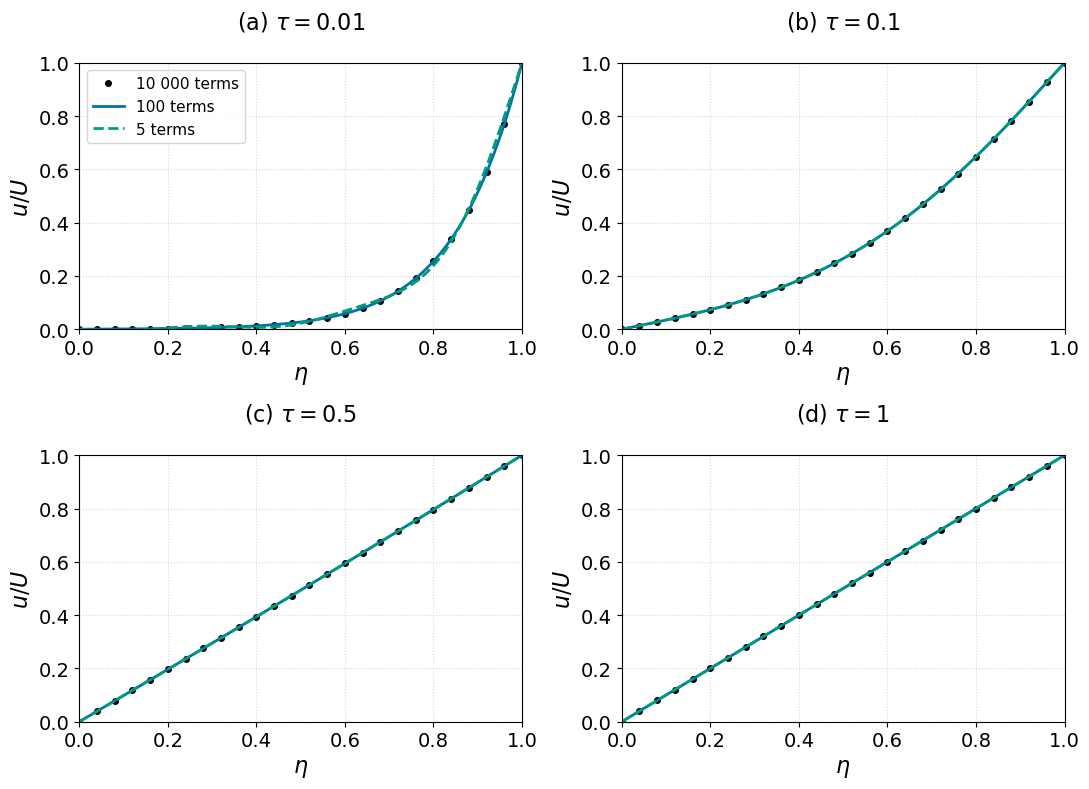

In [9]:
# Fig. 5.1 of Jordan (2005)
l = np.sqrt(0.01)
times = [0.01, 0.1, 0.5, 1.0]
eta = np.linspace(0, 1, 401)
eta_dots = np.linspace(0, 1, 26)
fig, axes = plt.subplots(2, 2, figsize=(11, 8), tight_layout=True)
for k in range(4):
    ax = axes[k//2, k % 2]
    tau = times[k]
    ax.plot(eta_dots, unsteadyv(eta_dots, tau, l, 10000), 'o', color='black', markersize=4, label='10 000 terms')
    ax.plot(eta, unsteadyv(eta, tau, l, 100), color='#0072B2', linewidth=2, label='100 terms')
    ax.plot(eta, unsteadyv(eta, tau, l, 5), color='#009E73', linewidth=2, linestyle='dashed', label='5 terms')
    ax.set_xlabel(r'$\eta$')
    ax.set_ylabel(r'$u/U$')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f'({"abcd"[k]}) ' + rf'$\tau = {tau:g}$')
    ax.grid(alpha=0.5, linestyle='dotted')
axes[0, 0].legend(loc='upper left', fontsize=11)
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/jordan_2005_fig5_1.png', dpi=200, bbox_inches='tight')

This is Fig. 5.2 of Jordan (2005): $u/U$ versus $\eta$ for $\tau$ = (a) 0.01, (b) 0.1, (c) 0.5, (d) 1, and $l = \sqrt{0.01}$, with Eq. (3.3) solid, Tzou's inversion (5.1) with $N = 10\,000$ dotted, and 100 terms of Eq. (16) of Hayat _et al._ (2004) broken.

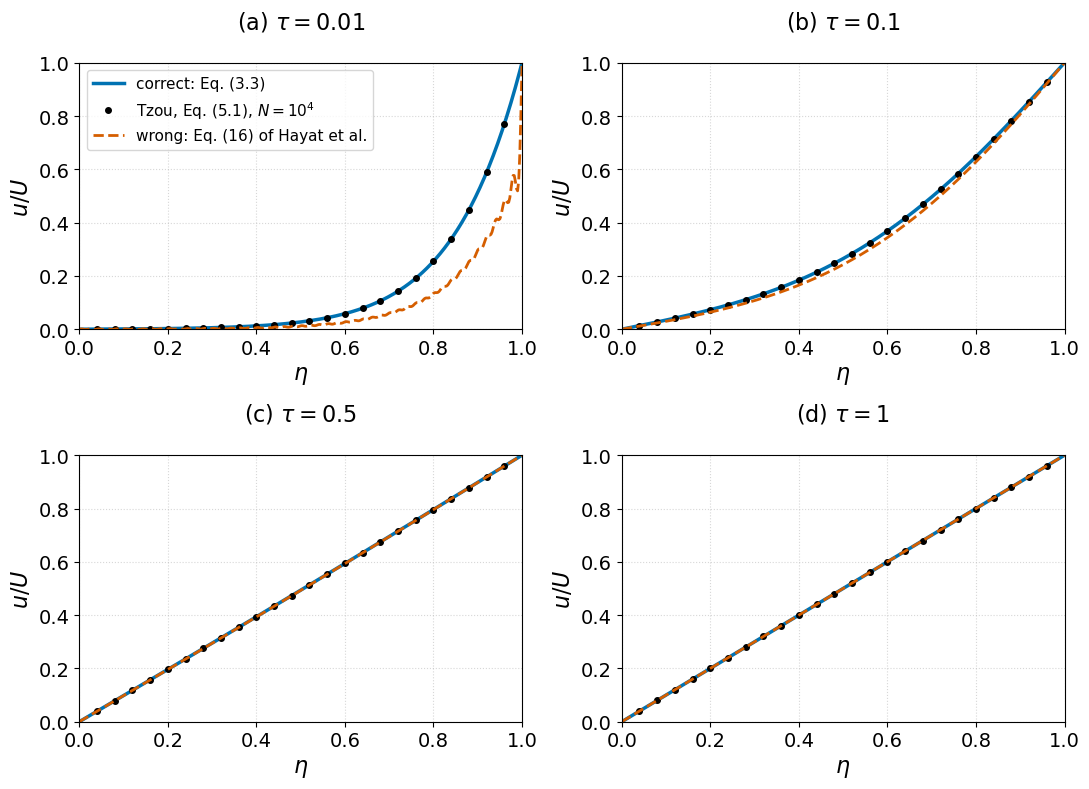

In [10]:
# Fig. 5.2 of Jordan (2005)
l = np.sqrt(0.01)
times = [0.01, 0.1, 0.5, 1.0]
eta = np.linspace(0, 1, 401)
eta_dots = np.linspace(0.04, 0.96, 24)
fig, axes = plt.subplots(2, 2, figsize=(11, 8), tight_layout=True)
for k in range(4):
    ax = axes[k//2, k % 2]
    tau = times[k]
    ax.plot(eta, unsteadyv(eta, tau, l, 100), color='#0072B2', linewidth=2.5, label='correct: Eq. (3.3)')
    ax.plot(eta_dots, tzou_inverse(lambda s: ubar(eta_dots, s, l), tau, 10000), 'o', color='black', markersize=4,
            label=r'Tzou, Eq. (5.1), $N=10^4$')
    ax.plot(eta, wrong_hayat_16(eta, tau, alpha1=l**2, nterms=100), color='#D55E00', linewidth=2, linestyle='dashed',
            label='wrong: Eq. (16) of Hayat et al.')
    ax.set_xlabel(r'$\eta$')
    ax.set_ylabel(r'$u/U$')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f'({"abcd"[k]}) ' + rf'$\tau = {tau:g}$')
    ax.grid(alpha=0.5, linestyle='dotted')
axes[0, 0].legend(loc='upper left', fontsize=11)
fig.savefig('../figures/jordan_2005_fig5_2.png', dpi=200, bbox_inches='tight')

These are Figs. 5.3 and 5.4 of Jordan (2005): (left) $u/U$ versus $\eta$ for $l = \sqrt{0.01}$, the start-up limit Eq. (4.1) and Eq. (3.3) at $\tau = 0.01$, $0.1$, $0.5$, $1$; (right) Eq. (4.1) for $l = \sqrt{0.05}$, $\sqrt{0.01}$, $\sqrt{0.001}$.

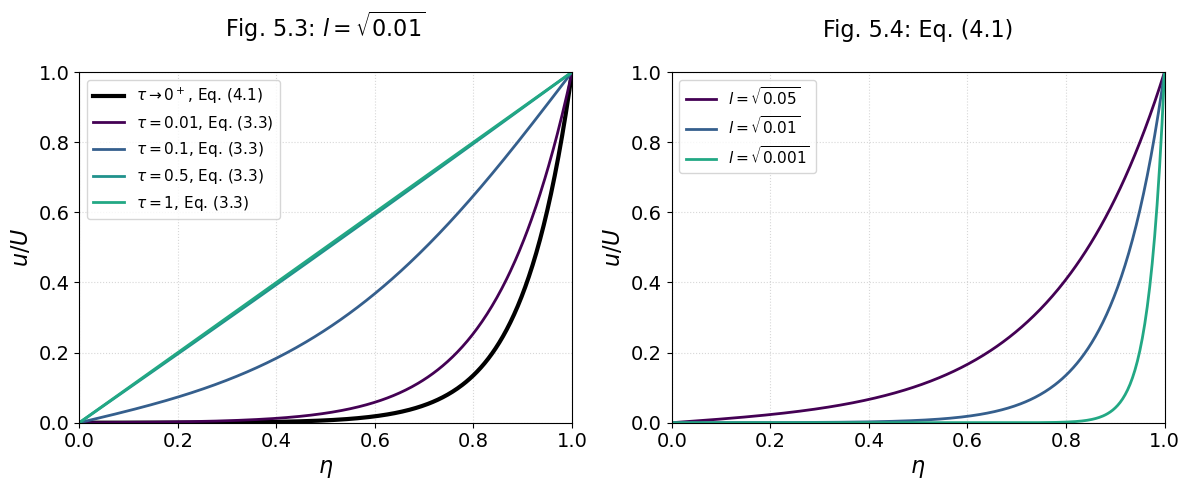

In [11]:
# Figs. 5.3 and 5.4 of Jordan (2005)
eta = np.linspace(0, 1, 401)
cmap = colormaps['viridis']
fig, axes = plt.subplots(1, 2, figsize=(12, 5), tight_layout=True)
l = np.sqrt(0.01)
axes[0].plot(eta, np.sinh(eta/l)/np.sinh(1/l), color='black', linewidth=3, label=r'$\tau\to0^+$, Eq. (4.1)')
times = [0.01, 0.1, 0.5, 1.0]
for k in range(len(times)):
    tau = times[k]
    axes[0].plot(eta, unsteadyv(eta, tau, l, 100), color=cmap(0.6*np.log(tau/0.01)/np.log(100)), linewidth=2,
                 label=rf'$\tau = {tau:g}$, Eq. (3.3)')
axes[0].set_title(r'Fig. 5.3: $l = \sqrt{0.01}$')
l_values = [np.sqrt(0.05), np.sqrt(0.01), np.sqrt(0.001)]
l_labels = [r'$l = \sqrt{0.05}$', r'$l = \sqrt{0.01}$', r'$l = \sqrt{0.001}$']
for k in range(3):
    lk = l_values[k]
    axes[1].plot(eta, np.sinh(eta/lk)/np.sinh(1/lk), color=cmap(0.6*k/2), linewidth=2, label=l_labels[k])
axes[1].set_title(r'Fig. 5.4: Eq. (4.1)')
for ax in axes:
    ax.set_xlabel(r'$\eta$')
    ax.set_ylabel(r'$u/U$')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.5, linestyle='dotted')
    ax.legend(loc='upper left', fontsize=11)
fig.savefig('../figures/jordan_2005_fig5_3_5_4.png', dpi=200, bbox_inches='tight')

Fig. 5.4 shows what sets the scale of the start-up jump. By Eq. (4.1) the profile at $\tau = 0^+$ is $\sinh[\eta/l]/\sinh[1/l]$, a layer of thickness $l = \sqrt{\alpha}/h$ at the moving plate: the second-grade fluid answers the plate's jump at once, over the length $\sqrt{\alpha}$ fixed by the normal-stress modulus, and the time $\tau$ does not enter, which is why Jordan (2005) calls this jump _stationary_, a nonpropagating vortex sheet across $\tau = 0$. (The Oldroyd-B fluid of the companion notebooks carries its jump into the fluid instead, at the finite speed of an elastic wave.) As $l\to0$ the layer thins and the jump vanishes: the Newtonian limit.

# EXPLORE IT YOURSELF

In [12]:
# Eq. (3.3) of Jordan (2005) and Eq. (16) of Hayat et al. (2004): plot function
def plot_func(l, tau):
    eta = np.linspace(0, 1, 201)   # fine grid for the envelope
    eta_arrows = np.linspace(0, 1, 16)   # about 15 arrows, one at the moving plate
    u = unsteadyv(eta, tau, l, 200)
    u_wrong = wrong_hayat_16(eta, tau, alpha1=l**2, nterms=200)
    jump = np.sinh(eta/l)/np.sinh(1/l)   # Eq. (4.1): the profile at tau = 0^+

    fig, ax = plt.subplots(tight_layout=True)
    ax.set_ylabel(r'$\eta$')
    ax.set_ylim(0, 1)
    ax.set_xlabel(r'$u/U$')
    ax.set_xlim(0, 1.1)
    ax.plot(eta, eta, color='gray', linewidth=1, label='steady state')
    ax.plot(jump, eta, color='black', linewidth=1, linestyle='dotted', label=r'$\tau\to0^+$: Eq. (4.1)')
    ax.plot(u, eta, color='darkblue', linewidth=4, label=rf'correct, $\tau={tau:.3f}$')
    ax.quiver(0*eta_arrows, eta_arrows, np.interp(eta_arrows, eta, u), 0*eta_arrows, scale=1., scale_units='xy', color='blue', zorder=3, clip_on=False)
    ax.plot(u_wrong, eta, color='#D55E00', linewidth=2, linestyle='dashed', label='wrong: Eq. (16)')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.5, linestyle='dotted')
    plt.show()

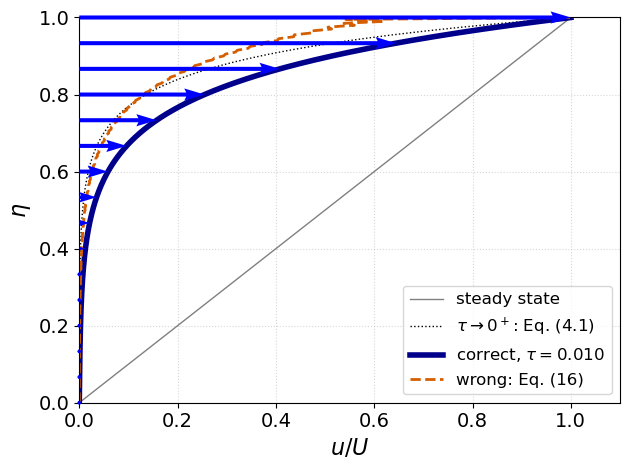

In [13]:
# Eq. (3.3) of Jordan (2005) and Eq. (16) of Hayat et al. (2004): static plot (the interactive widget below is stripped in the GitHub preview)
plot_func(np.sqrt(0.01), 0.01)

In [14]:
# Eq. (3.3) of Jordan (2005) and Eq. (16) of Hayat et al. (2004): interactive plot
interact(plot_func,
         l=widgets.FloatSlider(value=0.1, min=0.01, max=0.5, step=0.01, description='Length, l'),
         tau=widgets.FloatSlider(value=0.01, min=0.001, max=1, step=0.001, readout_format='.3f', description='Time, tau'));

In [15]:
# Eq. (3.3) of Jordan (2005) and Eq. (16) of Hayat et al. (2004): animation
l = np.sqrt(0.01)
eta = np.linspace(0, 1, 201)   # fine grid for the envelope
eta_arrows = np.linspace(0, 1, 16)   # about 15 arrows, one at the moving plate
u = unsteadyv(eta, 0.002, l, 200)

fig, ax = plt.subplots(tight_layout=True)
ax.set_ylabel(r'$\eta$')
ax.set_ylim(0, 1)
ax.set_xlabel(r'$u/U$')
ax.set_xlim(0, 1.1)
ax.grid(alpha=0.5, linestyle='dotted')
plt.close()

ax.plot(eta, eta, color='gray', linewidth=1, label='steady state')
line, = ax.plot(u, eta, color='darkblue', linewidth=4, label='correct')
line_wrong, = ax.plot(wrong_hayat_16(eta, 0.002, alpha1=l**2, nterms=200), eta, color='#D55E00',
                      linewidth=2, linestyle='dashed', label='wrong: Eq. (16)')
quiv = ax.quiver(0*eta_arrows, eta_arrows, np.interp(eta_arrows, eta, u), 0*eta_arrows, scale=1., scale_units='xy', color='blue', zorder=3, clip_on=False)
ax.legend(loc='lower right')

# number of animation frames
numframes = 50
tmax = 0.5

# animation function called sequentially by `FuncAnimation' below
def animate(i):
    # the i passed is the frame counter, rescaled to get the time
    tstar = (i + 1)/numframes*tmax
    u = unsteadyv(eta, tstar, l, 200)
    line.set_data(u, eta)
    line_wrong.set_data(wrong_hayat_16(eta, tstar, alpha1=l**2, nterms=200), eta)
    quiv.set_UVC(np.interp(eta_arrows, eta, u), 0*eta_arrows)
    line.set_label(rf'correct, $\tau={tstar:.3f}$')
    legend = ax.legend(loc='lower right')
    return (line, line_wrong, quiv, legend)

anim = animation.FuncAnimation(fig, animate, frames=numframes, interval=150, blit=True, repeat=False)

In [16]:
# this is necessary to get the animation to work on Google's Colab
rc('animation', html='jshtml')
anim

In [17]:
# To save the animation, use something like
# anim.save('jordan_2005_couette.mp4')

# WHAT PROBLEM DOES THE WRONG SOLUTION ACTUALLY SOLVE?

Mode by mode, the Laplace transform of Eq. (16) is that of Eq. (3.3) divided by $1+l^2s$. So Eq. (16) of Hayat _et al._ (2004) solves the IBVP (2.1)&ndash;(2.2) with the moving plate ramped on the retardation time $\alpha/\nu$ (that is, $l^2$ in units of $h^2/\nu$),
$$
    u(h,t) = U\left(1 - \mathrm{e}^{-\nu t/\alpha}\right)H(t),\qquad \bar{u}_\mathrm{wrong}(\eta,s) = \frac{\bar{u}(\eta,s)}{1+l^2s}.
$$
This identification is shown here; it is not stated in Jordan (2005). It extends to this problem the ramped plate that [I. C. Christov & C. I. Christov (2010)](https://arxiv.org/abs/1003.2188) found for Stokes' first problem of a second-grade fluid. The next cell computes the ratio of the $n$-th modes, including the sine series of the steady part $\eta$, $2(-1)^{n+1}/(n\pi s)$; it should print $1/(l^2s + 1)$.

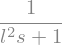

In [18]:
# Ratio of the Laplace transforms of the n-th modes of Eq. (16) of Hayat et al. (2004) and Eq. (3.3) of Jordan (2005)
l = sp.Symbol('l', positive=True)   # l was reused as a number above
lam = n**2*sp.pi**2
sigma = lam/(1 + l**2*lam)
steady = 2*(-1)**(n + 1)/(n*sp.pi*s)
mode_correct = steady + 2*(-1)**n/(n*sp.pi*(1 + l**2*lam)*(s + sigma))
mode_wrong = steady + 2*(-1)**n/(n*sp.pi*(s + sigma))
sp.simplify(mode_wrong/mode_correct)

The next cell compares Eq. (16) (20 000 terms) with the de Hoog inversion of $\bar{u}(\eta,s)/(1+l^2s)$; the difference should be limited by the truncation of the slowly converging series (16).

In [19]:
# Eq. (16) of Hayat et al. (2004) versus the ramped-plate solution, inverse of Eq. (3.1)/(1 + l^2 s)
l = np.sqrt(0.01)
eta = np.linspace(0.05, 0.95, 19)
max_difference = 0.0
for tau in [0.01, 0.1, 0.5, 1.0]:
    u_ramp = np.zeros_like(eta)
    for j in range(len(eta)):
        u_ramp[j] = float(mp.invertlaplace(lambda s: ubar_mp(s, eta[j], l)/(1 + l**2*s), tau, method='dehoog'))
    max_difference = max(max_difference, np.abs(wrong_hayat_16(eta, tau, alpha1=l**2, nterms=20000) - u_ramp).max())
print(f'max|Eq. (16), 20000 terms - ramped-plate solution| = {max_difference:.1e}')

max|Eq. (16), 20000 terms - ramped-plate solution| = 7.4e-05


# ON YOUR OWN

On your own:

*   Integrate Eq. (3.3) over $0<\eta<1$ and check the volume flux at start-up against Eq. (4.6) of Jordan (2005), $U^{-1}\lim_{\tau\to0^+}Q = l\tanh[(2l)^{-1}]$.
*   Show that $l \to 0$ in Eq. (3.3) gives the Newtonian series, and that Eq. (16) gives it too; why does that not validate Eq. (16)?
*   Repeat Fig. 5.2 for $l = \sqrt{0.05}$ and find when Eq. (16) is within 1% of Eq. (3.3).

# REFERENCES

I. C. Christov, C. I. Christov, Comment on &ldquo;On a class of exact solutions of the equations of motion of a second grade fluid&rdquo; by C. Fetec&#259;u and J. Zierep (Acta Mech. 150, 135&ndash;138, 2001), _Acta Mech._ **215** (2010) 25&ndash;28. [doi:10.1007/s00707-010-0300-2](https://doi.org/10.1007/s00707-010-0300-2); [arXiv:1003.2188](https://arxiv.org/abs/1003.2188)

F. R. de Hoog, J. H. Knight, A. N. Stokes, An improved method for numerical inversion of Laplace transforms, _SIAM J. Sci. Stat. Comput._ **3** (1982) 357&ndash;366. [doi:10.1137/0903022](https://doi.org/10.1137/0903022)

C. R. Harris, K. J. Millman, S. J. van der Walt, _et al._, Array programming with NumPy, _Nature_ **585** (2020) 357&ndash;362. [doi:10.1038/s41586-020-2649-2](https://doi.org/10.1038/s41586-020-2649-2)

J. D. Hunter, Matplotlib: A 2D graphics environment, _Comput. Sci. Eng._ **9** (2007) 90&ndash;95. [doi:10.1109/MCSE.2007.55](https://doi.org/10.1109/MCSE.2007.55)

P. M. Jordan, A note on start-up, plane Couette flow involving second-grade fluids, _Math. Probl. Eng._ **2005** (2005) 539&ndash;545. [doi:10.1155/MPE.2005.539](https://doi.org/10.1155/MPE.2005.539)

P. M. Jordan, P. Puri, Exact solutions for the unsteady plane Couette flow of a dipolar fluid, _Proc. R. Soc. Lond. A_ **458** (2002) 1245&ndash;1272. [doi:10.1098/rspa.2001.0917](https://doi.org/10.1098/rspa.2001.0917)

A. Meurer, C. P. Smith, M. Paprocki, _et al._, SymPy: symbolic computing in Python, _PeerJ Comput. Sci._ **3** (2017) e103. [doi:10.7717/peerj-cs.103](https://doi.org/10.7717/peerj-cs.103)

The mpmath development team, _mpmath: a Python library for arbitrary-precision floating-point arithmetic_ (version 1.3.0), 2023. [mpmath.org](https://mpmath.org/)

D. Y. Tzou, _Macro- to Microscale Heat Transfer: The Lagging Behavior_, Taylor & Francis, Washington, DC, 1997.

P. Virtanen, R. Gommers, T. E. Oliphant, _et al._, SciPy 1.0: fundamental algorithms for scientific computing in Python, _Nat. Methods_ **17** (2020) 261&ndash;272. [doi:10.1038/s41592-019-0686-2](https://doi.org/10.1038/s41592-019-0686-2)